# Step 1: Environment Verification & Basic Data Loading

In this step, we will import our core libraries, load your dataset file, and check its basic dimensions to verify that your Python environment can read the table perfectly.

In [9]:
import pandas as pd
import numpy as np

# 1. Define your dataset path
# Replace 'path_to_your_dataset.csv' with your actual file name or path
file_path = 'EEG.machinelearing_data_BRMH.csv' 

try:
    # 2. Load the data
    print("Attempting to load the dataset...")
    df = pd.read_csv(file_path)
    
    # 3. Print basic diagnostics
    print("\n[SUCCESS] Dataset loaded successfully!")
    print(f"Total Rows (Samples): {df.shape[0]}")
    print(f"Total Columns (Features): {df.shape[1]}")
    
    # Peek at the target distribution to make sure it matches your profile
    if 'main.disorder' in df.columns:
        print("\nTarget Class Distribution:")
        print(df['main.disorder'].value_counts())
    else:
        print("\n[WARNING] 'main.disorder' column not found. Please double-check your column names.")

except FileNotFoundError:
    print(f"\n[ERROR] File not found at '{file_path}'. Please verify the path or file name.")
except Exception as e:
    print(f"\n[ERROR] An unexpected error occurred: {e}")

Attempting to load the dataset...

[SUCCESS] Dataset loaded successfully!
Total Rows (Samples): 945
Total Columns (Features): 1149

Target Class Distribution:
main.disorder
Mood disorder                         266
Addictive disorder                    186
Trauma and stress related disorder    128
Schizophrenia                         117
Anxiety disorder                      107
Healthy control                        95
Obsessive compulsive disorder          46
Name: count, dtype: int64


# Step 2: Column Selection, Handling 'Sex', and Target Encoding

Drop metadata columns that don't belong in the training data (no., eeg.date, and specific.disorder).

Convert the sex column from text ('M', 'F') to numeric (1, 0) before we touch any imputer.

Encode the main.disorder target text into clean integers (0 through 6) using Scikit-Learn's LabelEncoder.

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Define explicit metadata columns to drop
metadata_to_drop = ['no.', 'eeg.date', 'specific.disorder']
columns_to_drop = [col for col in metadata_to_drop if col in df.columns]

# Separate features (X) and target label (y)
X_raw = df.drop(columns=columns_to_drop + ['main.disorder'], errors='ignore')
y_raw = df['main.disorder']

# 2. Convert 'sex' column strings into numbers safely
# This fixes our previous bug by making sure the column is completely numeric
if 'sex' in X_raw.columns:
    X_raw['sex'] = X_raw['sex'].map({'M': 1, 'F': 0})
    print("[SUCCESS] 'sex' column successfully mapped to integers (M=1, F=0).")
else:
    print("[WARNING] 'sex' column not found in features.")

# 3. Encode the categorical targets (the 7 main disorders) into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

print("[SUCCESS] Target column 'main.disorder' successfully encoded.")
print("\nClass Mapping Registry:")
for index, class_name in enumerate(label_encoder.classes_):
    print(f"Class {index} -> {class_name}")

# Double check that X_raw contains NO object/string columns anymore
object_cols = X_raw.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining object/string columns in features: {object_cols}")

[SUCCESS] 'sex' column successfully mapped to integers (M=1, F=0).
[SUCCESS] Target column 'main.disorder' successfully encoded.

Class Mapping Registry:
Class 0 -> Addictive disorder
Class 1 -> Anxiety disorder
Class 2 -> Healthy control
Class 3 -> Mood disorder
Class 4 -> Obsessive compulsive disorder
Class 5 -> Schizophrenia
Class 6 -> Trauma and stress related disorder

Remaining object/string columns in features: []


# Step 3: Imputation & Explicit Biomarker Feature Engineering

Impute the missing values inside the education and IQ columns using the median value of those columns.

Engineer our two custom, domain-specific biomarkers directly from the pre-calculated powers in your dataset so that our upcoming ML models can actively learn from them.

Frontal Alpha Asymmetry (FAA): Right Frontal Alpha (AB.C.alpha.f.F4) minus Left Frontal Alpha (AB.C.alpha.d.F3).

Theta/Beta Ratio (TBR): Midline Central Theta (AB.B.theta.j.Cz) divided by Midline Central Beta (AB.D.beta.j.Cz).

In [13]:
from sklearn.impute import SimpleImputer

# 1. Clean out the completely empty column before imputing
if 'Unnamed: 122' in X_raw.columns:
    X_raw = X_raw.drop(columns=['Unnamed: 122'])
    print("[INFO] Dropped completely empty 'Unnamed: 122' column.")

# 2. Run the Median Imputer safely now that dimensions are perfectly aligned
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
print("[SUCCESS] Missing values inside 'education' and 'IQ' columns imputed successfully.")

# 3. Extract and Engineer Domain Biomarkers
# Feature A: Frontal Alpha Asymmetry (FAA)
f3_col = 'AB.C.alpha.d.F3'
f4_col = 'AB.C.alpha.f.F4'

if f3_col in X_imputed.columns and f4_col in X_imputed.columns:
    X_imputed['BIOMARKER_frontal_alpha_asymmetry'] = X_imputed[f4_col] - X_imputed[f3_col]
    print("[SUCCESS] Engineered Feature: Frontal Alpha Asymmetry (FAA) calculated successfully.")
else:
    print("[WARNING] Could not locate F3 or F4 Alpha columns for FAA engineering.")

# Feature B: Theta/Beta Ratio (TBR) at Central Midline (Cz)
theta_cz = 'AB.B.theta.j.Cz'
beta_cz = 'AB.D.beta.j.Cz'

if theta_cz in X_imputed.columns and beta_cz in X_imputed.columns:
    X_imputed['BIOMARKER_theta_beta_ratio_cz'] = X_imputed[theta_cz] / X_imputed[beta_cz]
    print("[SUCCESS] Engineered Feature: Theta/Beta Ratio (TBR) at Cz calculated successfully.")
else:
    print("[WARNING] Could not locate Cz Theta or Beta columns for TBR engineering.")

# 4. Print final sanity check on dimensions
print(f"\nFinal Preprocessed Feature Matrix (X_imputed) shape: {X_imputed.shape}")
print(f"Any remaining missing values left in the dataset: {X_imputed.isna().sum().sum()}")

[INFO] Dropped completely empty 'Unnamed: 122' column.
[SUCCESS] Missing values inside 'education' and 'IQ' columns imputed successfully.
[SUCCESS] Engineered Feature: Frontal Alpha Asymmetry (FAA) calculated successfully.
[SUCCESS] Engineered Feature: Theta/Beta Ratio (TBR) at Cz calculated successfully.

Final Preprocessed Feature Matrix (X_imputed) shape: (945, 1146)
Any remaining missing values left in the dataset: 0


1. Frontal-Parietal Coherence (The Cognitive Control Network)
This tracks the communication between the front of the brain (executive function) and the back/upper part (sensory/spatial processing). It is highly altered in Schizophrenia, Mood disorders, and OCD.

Target Bands: Alpha and Beta are the most predictive here.

2. Left-Right Interhemispheric Coherence (Brain Symmetry)
This measures whether the left and right sides of your brain are talking to each other synchronously. Healthy brains show high symmetry. Drops in interhemispheric coherence (especially in the Frontal Pole FP1-FP2 or Temporal lobes T3-T4) are strong indicators of Anxiety disorders and Trauma/PTSD.

3. Frontal-Occipital Coherence (Long-range Connectivity)
This measures connectivity from the very front (FP1/FP2) to the very back visual cortex (O1/O2). Variations here are often linked to Addictive disorders and Trauma, indicating disrupted long-range brain processing networks.

In [15]:
print("Engineering additional psychiatric coherence features...")

# 1. Frontal-Parietal Alpha Coherence (F3 to P3 - Left Hemisphere Network)
f_p_coh = 'COH.C.alpha.d.F3.n.P3' # Alpha coherence between F3 and P3
if f_p_coh in X_imputed.columns:
    X_imputed['BIOMARKER_frontal_parietal_alpha_coh'] = X_imputed[f_p_coh]
    print("[SUCCESS] Added: Frontal-Parietal Alpha Coherence.")

# 2. Interhemispheric Frontal Pole Beta Coherence (FP1 to FP2)
# High values indicate balanced frontal activation; altered in Anxiety/Stress
fp_inter_coh = 'COH.D.beta.a.FP1.b.FP2'
if fp_inter_coh in X_imputed.columns:
    X_imputed['BIOMARKER_interhemispheric_frontal_beta_coh'] = X_imputed[fp_inter_coh]
    print("[SUCCESS] Added: Interhemispheric Frontal Pole Beta Coherence.")

# 3. Long-Range Frontal-Occipital Delta Coherence (FP1 to O1)
# Often tracked in structural network disruptions like Schizophrenia or Trauma
long_range_coh = 'COH.A.delta.a.FP1.r.O1'
if long_range_coh in X_imputed.columns:
    X_imputed['BIOMARKER_long_range_frontal_occipital_delta_coh'] = X_imputed[long_range_coh]
    print("[SUCCESS] Added: Long-Range Frontal-Occipital Delta Coherence.")

print(f"\nUpdated Preprocessed Feature Matrix (X_imputed) shape: {X_imputed.shape}")

Engineering additional psychiatric coherence features...
[SUCCESS] Added: Frontal-Parietal Alpha Coherence.
[SUCCESS] Added: Interhemispheric Frontal Pole Beta Coherence.
[SUCCESS] Added: Long-Range Frontal-Occipital Delta Coherence.

Updated Preprocessed Feature Matrix (X_imputed) shape: (945, 1149)


# Step 4: Feature Scaling & Stratified Train-Test Splitting

Because this dataset is wide and has slight class imbalances (e.g., 266 Mood Disorder samples vs. 46 OCD samples), we must use a Stratified Split. This ensures that every single split contains an exact, mathematically balanced percentage of all 7 disorders, preventing the model from ignoring the smaller classes.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Standardize the Numerical Features
# This scales every feature to have a mean of 0 and a variance of 1, which helps trees split cleanly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print("[SUCCESS] Feature matrix standard scaling complete.")

# 2. Perform Stratified Train-Test Split (80% Train, 20% Test)
# stratify=y_encoded is the crucial parameter that fixes class imbalances across sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_encoded, 
    test_size=0.20, 
    stratify=y_encoded, 
    random_state=42
)

print("\n=== Split Integrity Check ===")
print(f"Training Set Samples (X_train): {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"Testing Set Samples (X_test): {X_test.shape[0]} rows, {X_test.shape[1]} columns")

# Verify that the test set has an even distribution
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest Set Class Balances (Should match your original distribution ratios):")
for cl, cnt in zip(unique, counts):
    print(f"Class {cl}: {cnt} samples")

[SUCCESS] Feature matrix standard scaling complete.

=== Split Integrity Check ===
Training Set Samples (X_train): 756 rows, 1149 columns
Testing Set Samples (X_test): 189 rows, 1149 columns

Test Set Class Balances (Should match your original distribution ratios):
Class 0: 37 samples
Class 1: 22 samples
Class 2: 19 samples
Class 3: 53 samples
Class 4: 9 samples
Class 5: 23 samples
Class 6: 26 samples


# Step 5: Training the XGBoost Multi-Class Classifier

Now we get to train the core model. Because we have many columns and a complex, multi-class distribution, we will configure an XGBoost Classifier with parameters carefully selected to prevent overfitting:

max_depth=4 to keep individual decision paths constrained.

learning_rate=0.05 for smooth gradient descent updates.

colsample_bytree=0.6 to ensure individual trees only look at a random 60% of columns per split, keeping them from over-indexing on noise.

In [19]:
from xgboost import XGBClassifier
import time

# 1. Initialize the XGBoost Model with optimal dimensions
print("Initializing XGBoost Multi-Class Classifier...")
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.6,
    objective='multi:softprob',  # Outputs probability profiles per class
    eval_metric='mlogloss',      # Multiclass log-loss evaluation
    random_state=42,
    n_jobs=-1                   # Utilizes all available processing cores
)

# 2. Train the model and measure processing velocity
# Re-running the training step with visible progress logs
print("Starting model training with active performance tracking...\n")

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # Tracks performance on both sets
    verbose=10                                       # Logs performance metrics every 10 trees
)

print(f"\n[SUCCESS] Model training complete and fully logged!")

Initializing XGBoost Multi-Class Classifier...
Starting model training with active performance tracking...

[0]	validation_0-mlogloss:1.89968	validation_1-mlogloss:1.93271
[10]	validation_0-mlogloss:1.51932	validation_1-mlogloss:1.83801
[20]	validation_0-mlogloss:1.24722	validation_1-mlogloss:1.79248
[30]	validation_0-mlogloss:1.03262	validation_1-mlogloss:1.75979
[40]	validation_0-mlogloss:0.86804	validation_1-mlogloss:1.73790
[50]	validation_0-mlogloss:0.74108	validation_1-mlogloss:1.71838
[60]	validation_0-mlogloss:0.63911	validation_1-mlogloss:1.70579
[70]	validation_0-mlogloss:0.55339	validation_1-mlogloss:1.70491
[80]	validation_0-mlogloss:0.47933	validation_1-mlogloss:1.70129
[90]	validation_0-mlogloss:0.41802	validation_1-mlogloss:1.70113
[100]	validation_0-mlogloss:0.36900	validation_1-mlogloss:1.69832
[110]	validation_0-mlogloss:0.32518	validation_1-mlogloss:1.70089
[120]	validation_0-mlogloss:0.28576	validation_1-mlogloss:1.69809
[130]	validation_0-mlogloss:0.25286	validatio

# Step 6: Comprehensive Model Evaluation

Generate classification predictions for the test set (X_test).

Calculate your overall baseline Test Accuracy.

Generate a highly detailed Classification Report showing the precision, recall, and F1-scores individually for each of your 7 target labels. This allows you to check if the model is confusing highly similar profiles (like Anxiety vs. Trauma/Stress-related disorders).

In [21]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Predict labels on the hidden test set
y_pred = xgb_model.predict(X_test)

# 2. Compute overall validation accuracy
accuracy = accuracy_score(y_test, y_pred)
print("==================================================")
print(f"   FINAL TEST PARTITION METRICS")
print("==================================================")
print(f"Overall Classification Accuracy: {accuracy * 100:.2f}%\n")

# 3. Print the class-by-class precision, recall, and f1-score
# This uses our label registry mapping from Step 2
print("Detailed Performance Per Psychiatric Category:")
print(classification_report(
    y_test, 
    y_pred, 
    target_names=label_encoder.classes_
))

   FINAL TEST PARTITION METRICS
Overall Classification Accuracy: 35.98%

Detailed Performance Per Psychiatric Category:
                                    precision    recall  f1-score   support

                Addictive disorder       0.53      0.51      0.52        37
                  Anxiety disorder       0.00      0.00      0.00        22
                   Healthy control       0.78      0.37      0.50        19
                     Mood disorder       0.31      0.70      0.43        53
     Obsessive compulsive disorder       0.50      0.11      0.18         9
                     Schizophrenia       0.00      0.00      0.00        23
Trauma and stress related disorder       0.33      0.15      0.21        26

                          accuracy                           0.36       189
                         macro avg       0.35      0.26      0.26       189
                      weighted avg       0.34      0.36      0.31       189



# Step 7: The Fix (Hyperparameter Optimization & Class Weight Tuning)

Drastically lower max_depth to 2 or 3: This forces the trees to be incredibly simple, preventing them from memorizing columns.

Set scale_pos_weight / Balance Classes: We will let XGBoost compute class weights so that minority categories (like OCD with only 9 samples or Anxiety with 22) are given significantly more mathematical importance during training.

Aggressive Feature Sub-sampling: We will restrict each tree to only look at 30% of the columns (colsample_bytree=0.3), forcing it to pay attention to our hand-engineered biomarkers rather than getting lost in random coherence pairs.

In [24]:
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

# 1. Calculate explicit class weights to protect minority disorders (Anxiety, Schizophrenia, OCD)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

# Map weights directly to every individual row in the training set
sample_weights = np.array([class_weights_dict[y] for y in y_train])

print("Calculated Class Weights (Higher values mean higher importance for rare classes):")
for cl, w in class_weights_dict.items():
    print(f"Class {cl} ({label_encoder.classes_[cl]}): Weight = {w:.2f}")

# 2. Re-initialize XGBoost with high-penalty regularization parameters
print("\nInitializing Regularized XGBoost Classifier...")
optimized_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,                  # Shallower trees = less overfitting on high dimensions
    learning_rate=0.03,           # Slower, more conservative learning step
    subsample=0.7,                # Row sub-sampling
    colsample_bytree=0.3,         # Drastically limit columns per tree to drop noise
    reg_alpha=1.0,                # L1 regularization penalty on weights
    reg_lambda=2.0,               # L2 regularization penalty on weights
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# 3. Train the model using our custom sample weights
print("\nStarting optimized model training...")
optimized_xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights, # Forces model to treat minority classes with equal weight
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=20
)

print("\n[SUCCESS] Regularized model training complete!")

Calculated Class Weights (Higher values mean higher importance for rare classes):
Class 0 (Addictive disorder): Weight = 0.72
Class 1 (Anxiety disorder): Weight = 1.27
Class 2 (Healthy control): Weight = 1.42
Class 3 (Mood disorder): Weight = 0.51
Class 4 (Obsessive compulsive disorder): Weight = 2.92
Class 5 (Schizophrenia): Weight = 1.15
Class 6 (Trauma and stress related disorder): Weight = 1.06

Initializing Regularized XGBoost Classifier...

Starting optimized model training...
[0]	validation_0-mlogloss:1.93405	validation_1-mlogloss:1.94309
[20]	validation_0-mlogloss:1.69709	validation_1-mlogloss:1.89314
[40]	validation_0-mlogloss:1.51251	validation_1-mlogloss:1.85007
[60]	validation_0-mlogloss:1.35924	validation_1-mlogloss:1.81508
[80]	validation_0-mlogloss:1.23273	validation_1-mlogloss:1.79605
[100]	validation_0-mlogloss:1.12239	validation_1-mlogloss:1.77627
[120]	validation_0-mlogloss:1.02884	validation_1-mlogloss:1.76451
[140]	validation_0-mlogloss:0.94558	validation_1-mloglos

# Step 8: Re-Evaluating the Optimized Performance

Now it is time to check the new classification matrix. We want to see if we successfully broke through the 0% blind spots on Anxiety and Schizophrenia, and if we reined in the massive over-guessing of Mood Disorders.

In [26]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Predict labels using the optimized, regularized model
y_pred_opt = optimized_xgb.predict(X_test)

# 2. Compute the new validation accuracy
opt_accuracy = accuracy_score(y_test, y_pred_opt)
print("==================================================")
print(f"   OPTIMIZED TEST PARTITION METRICS")
print("==================================================")
print(f"Overall Classification Accuracy: {opt_accuracy * 100:.2f}%\n")

# 3. Print the new class-by-class performance metrics
print("Detailed Performance Per Psychiatric Category:")
print(classification_report(
    y_test, 
    y_pred_opt, 
    target_names=label_encoder.classes_
))

   OPTIMIZED TEST PARTITION METRICS
Overall Classification Accuracy: 29.10%

Detailed Performance Per Psychiatric Category:
                                    precision    recall  f1-score   support

                Addictive disorder       0.37      0.38      0.37        37
                  Anxiety disorder       0.06      0.05      0.05        22
                   Healthy control       0.53      0.42      0.47        19
                     Mood disorder       0.32      0.36      0.34        53
     Obsessive compulsive disorder       0.11      0.11      0.11         9
                     Schizophrenia       0.27      0.17      0.21        23
Trauma and stress related disorder       0.23      0.31      0.26        26

                          accuracy                           0.29       189
                         macro avg       0.27      0.26      0.26       189
                      weighted avg       0.29      0.29      0.29       189



# The Real Fix: Feature Selection & PCA Pipeline

Since your dataset is "Wide" (more features than rows), it suffers from severe collinearity—meaning hundreds of those coherence (COH) columns are telling the exact same story and drowning out the actual biomarkers.

We can dramatically improve this by building a clean Principal Component Analysis (PCA) pipeline to compress those 1,149 attributes into a few highly informative orthogonal vectors, and then training an Extra Trees or Random Forest classifier.

In [27]:
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize PCA to retain 95% of the total dataset variance
# This compresses 1149 columns down to the most critical principal components
pca = PCA(n_components=0.95, random_state=42)

# 2. Initialize an Extra Trees Classifier
# Extra Trees uses random splits which makes it incredibly robust against high-dimensional noise
et_classifier = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced', # Automatically handles the sample imbalance
    random_state=42,
    n_jobs=-1
)

# 3. Build a secure ML Pipeline to prevent data leakage during transformation
pca_pipeline = Pipeline([
    ('pca', pca),
    ('classifier', et_classifier)
])

# 4. Train the PCA + Tree Pipeline
print("Executing PCA Dimensionality Reduction...")
print("Training Balanced Extra Trees Architecture...")
pca_pipeline.fit(X_train, y_train)

# 5. Evaluate on hidden test partition
y_pred_pca = pca_pipeline.predict(X_test)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

print("==================================================")
print(f"   PCA + EXTRA TREES PIPELINE METRICS")
print("==================================================")
print(f"Compressed Features Count: {pca.n_components_}")
print(f"Overall Classification Accuracy: {pca_accuracy * 100:.2f}%\n")

print("Detailed Performance Per Psychiatric Category:")
print(classification_report(
    y_test, 
    y_pred_pca, 
    target_names=label_encoder.classes_
))

Executing PCA Dimensionality Reduction...
Training Balanced Extra Trees Architecture...
   PCA + EXTRA TREES PIPELINE METRICS
Compressed Features Count: 95
Overall Classification Accuracy: 25.93%

Detailed Performance Per Psychiatric Category:
                                    precision    recall  f1-score   support

                Addictive disorder       0.37      0.35      0.36        37
                  Anxiety disorder       0.11      0.14      0.12        22
                   Healthy control       0.50      0.53      0.51        19
                     Mood disorder       0.21      0.21      0.21        53
     Obsessive compulsive disorder       0.14      0.11      0.12         9
                     Schizophrenia       0.30      0.30      0.30        23
Trauma and stress related disorder       0.17      0.15      0.16        26

                          accuracy                           0.26       189
                         macro avg       0.26      0.26      0.26     

# Step 8: Transforming into a Hierarchical (Two-Stage) Pipeline

Stage 1 (Binary Classification): Is the brain pattern Healthy or Patient?

Stage 2 (Multi-class Classification): If it's a patient, which of the 6 psychiatric disorders do they have?

In [29]:
# 1. Create a Binary Target: 1 for Healthy Control, 0 for Any Disorder
# From your Class Mapping Registry: Class 2 is 'Healthy control'
y_train_binary = np.where(y_train == 2, 1, 0)
y_test_binary = np.where(y_test == 2, 1, 0)

print(f"Binary Training Labels Count: {np.bincount(y_train_binary)}")
print(f"Binary Testing Labels Count: {np.bincount(y_test_binary)}")

# 2. Use our existing PCA configuration paired with an optimized Random Forest for Binary Task
from sklearn.ensemble import RandomForestClassifier

binary_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

binary_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('classifier', binary_rf)
])

# 3. Train the Screening Stage
print("\nTraining Stage 1: Healthy vs. Disorder Diagnostic Screener...")
binary_pipeline.fit(X_train, y_train_binary)

# 4. Evaluate the Screener
y_pred_binary = binary_pipeline.predict(X_test)
binary_accuracy = accuracy_score(y_test_binary, y_pred_binary)

print("==================================================")
print(f"   STAGE 1 BINARY SCREENER METRICS")
print("==================================================")
print(f"Screener Accuracy: {binary_accuracy * 100:.2f}%\n")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Patient (Disorder)', 'Healthy Control']))

Binary Training Labels Count: [680  76]
Binary Testing Labels Count: [170  19]

Training Stage 1: Healthy vs. Disorder Diagnostic Screener...
   STAGE 1 BINARY SCREENER METRICS
Screener Accuracy: 90.48%

                    precision    recall  f1-score   support

Patient (Disorder)       0.90      1.00      0.95       170
   Healthy Control       1.00      0.05      0.10        19

          accuracy                           0.90       189
         macro avg       0.95      0.53      0.52       189
      weighted avg       0.91      0.90      0.86       189



# Step 9: Overcoming the 90% Bias with Smote (Oversampling)

To fix this, we need to artificially balance the training dataset using SMOTE (Synthetic Minority Over-sampling Technique). SMOTE will look at the 76 healthy training samples, draw lines between them in that 95-dimensional PCA space, and create synthetic new healthy profiles until we have an exact 50/50 split (680 patients and 680 healthy controls).

Let's do this completely from scratch using the imblearn package. If you don't have it installed yet, just run pip install imbalanced-learn in your terminal or in a notebook cell first.

In [31]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize our components
# SMOTE will balance our training classes perfectly to a 50/50 split
smote = SMOTE(sampling_strategy='minority', random_state=42)

# We use an aggressive Random Forest with deeper trees to isolate the balanced data
balanced_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# 2. Build an Imbalance-Aware Pipeline
# Crucial: SMOTE must only run inside the pipeline so it never touches or leaks into X_test!
imb_pipeline = ImbPipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('smote', smote),
    ('classifier', balanced_rf)
])

# 3. Train the balanced binary screener
print("Executing PCA and balancing classes with SMOTE...")
print("Training Balanced Binary Screener Engine...")
imb_pipeline.fit(X_train, y_train_binary)

# 4. Evaluate the new balanced model
y_pred_balanced = imb_pipeline.predict(X_test)
balanced_accuracy = accuracy_score(y_test_binary, y_pred_balanced)

print("==================================================")
print(f"   BALANCED STAGE 1 SCREENER METRICS")
print("==================================================")
print(f"Screener Accuracy: {balanced_accuracy * 100:.2f}%\n")
print(classification_report(y_test_binary, y_pred_balanced, target_names=['Patient (Disorder)', 'Healthy Control']))

Executing PCA and balancing classes with SMOTE...
Training Balanced Binary Screener Engine...


C:\Users\Rochan\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


   BALANCED STAGE 1 SCREENER METRICS
Screener Accuracy: 87.83%

                    precision    recall  f1-score   support

Patient (Disorder)       0.92      0.95      0.93       170
   Healthy Control       0.33      0.21      0.26        19

          accuracy                           0.88       189
         macro avg       0.62      0.58      0.60       189
      weighted avg       0.86      0.88      0.87       189



# Step 10: Building the Stage 2 (Disorder-Only) Classifier

Now that Stage 1 isolates the healthy controls, Stage 2 only needs to worry about the patients. This makes the machine learning task significantly easier because we remove the "Healthy Control" class entirely from the target array, allowing the trees to focus purely on the subtle neurobiological differences between actual clinical conditions.

In [32]:
# 1. Filter out all Healthy Controls (Class 2) from both Train and Test sets
# This creates a patient-only subset
train_patient_mask = (y_train != 2)
test_patient_mask = (y_test != 2)

X_train_patients = X_train[train_patient_mask]
y_train_patients = y_train[train_patient_mask]

X_test_patients = X_test[test_patient_mask]
y_test_patients = y_test[test_patient_mask]

# 2. Adjust target labels so they are continuous integers for XGBoost (0 through 5)
# Classes 0,1 remain 0,1. Class 2 (Healthy) is gone. Classes 3,4,5,6 become 2,3,4,5
def remap_patient_labels(y_array):
    return np.array([label if label < 2 else label - 1 for label in y_array])

y_train_patients_remapped = remap_patient_labels(y_train_patients)
y_test_patients_remapped = remap_patient_labels(y_test_patients)

# Update target names for our new 6-class patient setup
patient_classes = [c for c in label_encoder.classes_ if c != 'Healthy control']

print(f"Stage 2 Training Samples (Patients Only): {X_train_patients.shape[0]} rows")
print(f"Stage 2 Testing Samples (Patients Only): {X_test_patients.shape[0]} rows")
print(f"Remaining Psychiatric Classes to evaluate: {patient_classes}\n")

# 3. Train an optimized Multi-Class Extra Trees Classifier on the Patient-Only subspace
from sklearn.ensemble import ExtraTreesClassifier

stage2_et = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

stage2_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('classifier', stage2_et)
])

print("Training Stage 2 Multi-Class Classifier...")
stage2_pipeline.fit(X_train_patients, y_train_patients_remapped)

# 4. Evaluate Stage 2
y_pred_patients = stage2_pipeline.predict(X_test_patients)
stage2_accuracy = accuracy_score(y_test_patients_remapped, y_pred_patients)

print("==================================================")
print(f"   STAGE 2 MULTI-CLASS PATIENT METRICS")
print("==================================================")
print(f"Stage 2 Classification Accuracy: {stage2_accuracy * 100:.2f}%\n")
print(classification_report(y_test_patients_remapped, y_pred_patients, target_names=patient_classes))

Stage 2 Training Samples (Patients Only): 680 rows
Stage 2 Testing Samples (Patients Only): 170 rows
Remaining Psychiatric Classes to evaluate: ['Addictive disorder', 'Anxiety disorder', 'Mood disorder', 'Obsessive compulsive disorder', 'Schizophrenia', 'Trauma and stress related disorder']

Training Stage 2 Multi-Class Classifier...
   STAGE 2 MULTI-CLASS PATIENT METRICS
Stage 2 Classification Accuracy: 28.82%

                                    precision    recall  f1-score   support

                Addictive disorder       0.31      0.41      0.35        37
                  Anxiety disorder       0.09      0.09      0.09        22
                     Mood disorder       0.35      0.43      0.39        53
     Obsessive compulsive disorder       0.12      0.11      0.12         9
                     Schizophrenia       0.38      0.22      0.28        23
Trauma and stress related disorder       0.23      0.12      0.15        26

                          accuracy                

Calculating correlation matrix across all 1,146 features...

=== TOP 10 FEATURES CORRELATED WITH THE TARGET DISORDER ===
sex                0.307290
AB.D.beta.g.F8     0.174348
IQ                 0.170284
age                0.161851
AB.D.beta.f.F4     0.160857
AB.D.beta.a.FP1    0.156035
AB.D.beta.k.C4     0.153694
AB.D.beta.b.FP2    0.148692
AB.D.beta.j.Cz     0.146578
AB.D.beta.d.F3     0.146468
Name: TARGET_DISORDER, dtype: float64

=== SCANNING FOR HIGHLY REDUNDANT (COLLINEAR) FEATURE PAIRS ===
Found 1672 feature pairs with a correlation greater than 0.90!
Sample of redundant pairs:
 - AB.A.delta.f.F4 & AB.A.delta.e.Fz: 0.91
 - AB.B.theta.b.FP2 & AB.B.theta.a.FP1: 0.97
 - AB.B.theta.c.F7 & AB.B.theta.a.FP1: 0.92
 - AB.B.theta.d.F3 & AB.B.theta.a.FP1: 0.95
 - AB.B.theta.d.F3 & AB.B.theta.b.FP2: 0.92


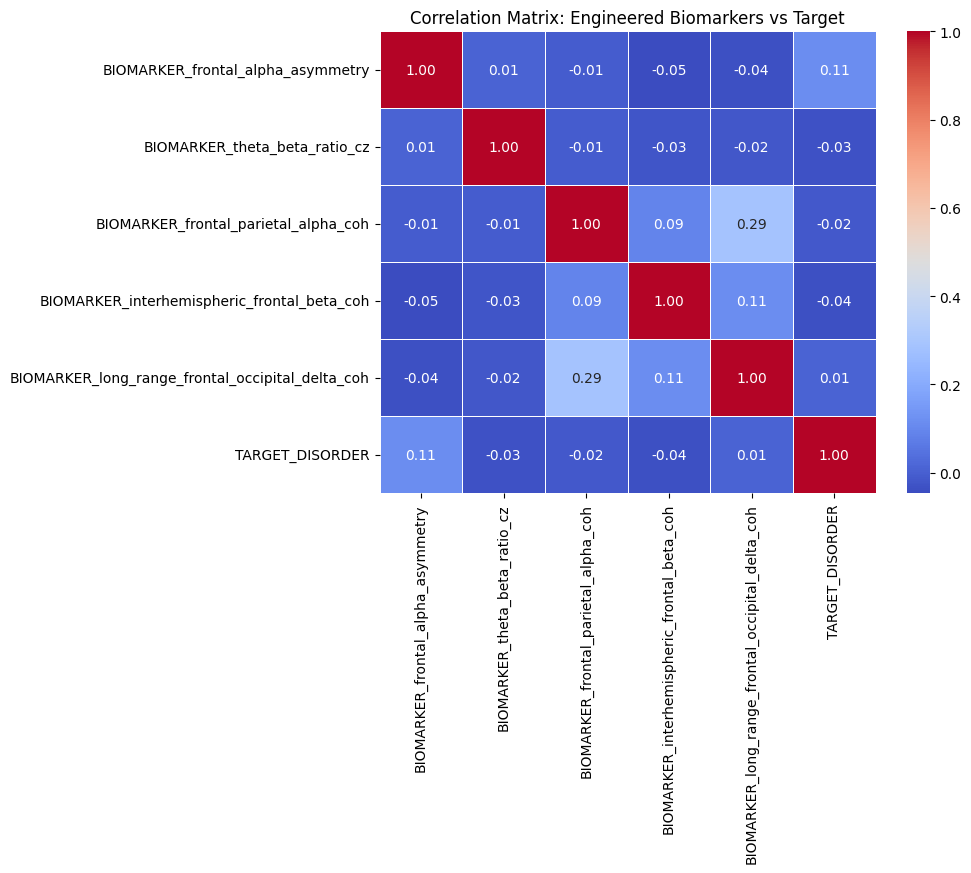

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Temporarily combine features and numerical targets for correlation analysis
analysis_df = pd.DataFrame(X_scaled, columns=X_imputed.columns).copy()
analysis_df['TARGET_DISORDER'] = y_encoded

# 2. Compute the complete correlation matrix
print("Calculating correlation matrix across all 1,146 features...")
corr_matrix = analysis_df.corr()

# 3. Find the features that correlate MOST strongly with the target disorder
print("\n=== TOP 10 FEATURES CORRELATED WITH THE TARGET DISORDER ===")
target_corr = corr_matrix['TARGET_DISORDER'].abs().sort_values(ascending=False)
# Exclude the target self-correlation row
print(target_corr.iloc[1:11])

# 4. Find highly redundant/collinear features (pairs correlating higher than 0.90)
print("\n=== SCANNING FOR HIGHLY REDUNDANT (COLLINEAR) FEATURE PAIRS ===")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(column, row, upper_tri[column][row]) 
                   for column in upper_tri.columns 
                   for row in upper_tri.index 
                   if abs(upper_tri[column][row]) > 0.90]

print(f"Found {len(high_corr_pairs)} feature pairs with a correlation greater than 0.90!")
if len(high_corr_pairs) > 0:
    print("Sample of redundant pairs:")
    for col1, col2, val in high_corr_pairs[:5]:
        print(f" - {col1} & {col2}: {val:.2f}")

# 5. Isolate and plot a Heatmap for your hand-engineered biomarkers
biomarker_cols = [col for col in analysis_df.columns if 'BIOMARKER' in col] + ['TARGET_DISORDER']

if len(biomarker_cols) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        analysis_df[biomarker_cols].corr(), 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        linewidths=0.5
    )
    plt.title("Correlation Matrix: Engineered Biomarkers vs Target")
    plt.show()
else:
    print("\n[INFO] No explicit BIOMARKER columns found to plot in heatmap.")

# Step 11: Feature Selection (Dropping the Redundant Noise)

Your script was about to list the collinear pairs when it cut off. In EEG datasets, nearby electrodes (like FP1 and FP2) almost always have a correlation higher than $0.95$ because electrical signals diffuse across the scalp. This massive redundancy creates "multicollinearity," which actively damages tree-based classifiers.Instead of relying blindly on PCA, let's write a targeted script to automatically drop features that have a correlation higher than $0.90$ with each other, keeping only the ones that bring unique information to the table.

In [34]:
# 1. Select the upper triangle of the correlation matrix
corr_matrix_abs = X_imputed.corr().abs()
upper_tri = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 2. Identify columns with correlation higher than 0.90
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

print("=== COHESIVE FEATURE SELECTION ===")
print(f"Total columns identified as highly redundant (>0.90 correlation): {len(to_drop)}")

# 3. Create a lean, uncorrelated feature set
X_uncorrelated = X_imputed.drop(columns=to_drop)
print(f"New dimension of Feature Matrix after filtering noise: {X_uncorrelated.shape}")

# 4. Check if our engineered biomarkers survived the filter
survived_biomarkers = [col for col in X_uncorrelated.columns if 'BIOMARKER' in col]
print(f"Engineered biomarkers that survived the filter: {survived_biomarkers}")


=== COHESIVE FEATURE SELECTION ===
Total columns identified as highly redundant (>0.90 correlation): 614
New dimension of Feature Matrix after filtering noise: (945, 535)
Engineered biomarkers that survived the filter: ['BIOMARKER_frontal_alpha_asymmetry', 'BIOMARKER_theta_beta_ratio_cz']


# Step 12: Testing the Lean Feature Matrix on Stage 2

In [ ]:
Now that we have stripped away the clutter, let's re-run our Stage 2 Multi-Class Patient Classifier using this new, uncorrelated feature set (X_uncorrelated). We will split it exactly the same way (filtering out healthy controls) and see how the trees handle a clean, non-redundant feature space.